# Clasificacion Politica de Noticias Colombianas con BETO

Clasifica noticias en tres espectros politicos usando la fuente como etiqueta:

| Clase | Medios |
|-------|--------|
| CENTRO | El Espectador, Ultima Hora Col |
| DERECHA | El Tiempo, Semana |
| IZQUIERDA | RTVC, Colombia Informa |

Modelo: `dccuchile/bert-base-spanish-wwm-cased` (BETO)

## Celda 1 - Instalacion

In [ ]:
!pip install transformers datasets torch pandas requests beautifulsoup4 newspaper3k scikit-learn seaborn matplotlib tqdm -q
print('Librerias instaladas')
!pip install lxml_html_clean

## Celda 2 - Imports

In [ ]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import time
import random
import os
import warnings
warnings.filterwarnings('ignore')
from newspaper import Article
from tqdm import tqdm
import torch
from transformers import BertTokenizerFast, BertForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

memoria = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {memoria}')


## Celda 3 - Montar Google Drive

Guarda el CSV en Drive para no perderlo si se reinicia Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/ProyectoBert/'
os.makedirs(SAVE_PATH, exist_ok=True)
CSV_PATH = SAVE_PATH + 'noticias.csv'
MODEL_PATH = SAVE_PATH + 'modelo_beto/'
print(f'Carpeta: {SAVE_PATH}')

## Celda 4 - Scraper

Extrae noticias de politica de cada medio usando `newspaper3k`.
Usa la fuente como etiqueta politica.

In [ ]:
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
    'Accept-Language': 'es-CO,es;q=0.9,en;q=0.8',
    'Accept-Encoding': 'gzip, deflate, br',
    'Connection': 'keep-alive',
    'Upgrade-Insecure-Requests': '1'
}

FUENTES = {
    'CENTRO':    [{'nombre': 'El Espectador', 'url': 'https://www.elespectador.com/politica/'},
                  {'nombre': 'El Colombiano', 'url': 'https://www.elcolombiano.com/colombia/politica'},
                  {'nombre': 'Bluradio',      'url': 'https://www.bluradio.com/nacion'}],
    'DERECHA':   [{'nombre': 'El Tiempo',     'url': 'https://www.eltiempo.com/politica/'},
                  {'nombre': 'Semana',         'url': 'https://www.semana.com/nacion/'}],
    'IZQUIERDA': [{'nombre': 'Colombia Informa', 'url': 'https://www.colombiainforma.info/categoria/politica/'},
                  {'nombre': 'Desde Abajo',      'url': 'https://www.desdeabajo.info/colombia'},
                  {'nombre': 'El Turbion',        'url': 'https://elturbion.com/?cat=4'},
                  {'nombre': 'Palabras al Margen','url': 'https://palabrasalmargen.com/categoria/nacional/'}]
}

def get_article_links(url, max_links=100):
    try:
        session = requests.Session()
        session.headers.update(HEADERS)
        resp = session.get(url, timeout=20)
        soup = BeautifulSoup(resp.text, 'html.parser')
        base = url.split('/')[0] + '//' + url.split('/')[2]
        links = set()
        for a in soup.find_all('a', href=True):
            href = a['href']
            if href.startswith('/'):
                href = base + href
            if base in href and len(href) > len(url) + 5 and '#' not in href:
                links.add(href)
        print(f'    {len(links)} links encontrados en {base}')
        return list(links)[:max_links]
    except Exception as e:
        print(f'  Error obteniendo links: {e}')
        return []

def scrape_article(url):
    try:
        art = Article(url, language='es')
        art.download()
        art.parse()
        if art.title and art.text and len(art.text) > 100:
            return art.title.strip() + '. ' + art.text[:400].strip()
    except:
        pass
    return None

def scrape_fuente(nombre, url, clase, n=100):
    print(f'\n  Scrapeando {nombre} ({clase})...')
    links = get_article_links(url, max_links=n * 4)
    datos = []
    errores = 0
    for link in links:
        texto = scrape_article(link)
        if texto:
            datos.append({'texto': texto, 'clase': clase, 'fuente': nombre, 'url': link})
            errores = 0
        else:
            errores += 1
        if errores >= 20:
            print(f'  Demasiados errores en {nombre}, saltando...')
            break
        time.sleep(random.uniform(1.0, 2.5))
        if len(datos) >= n:
            break
    print(f'  -> {len(datos)} articulos de {nombre}')
    return datos

print('Scraper listo')

## Celda 5 - Ejecutar Scraper y Guardar CSV

**AVISO:** Tarda 20-40 minutos. Si ya tenes el CSV en Drive, salta a la Celda 6.

In [ ]:
todos_los_datos = []
for clase, fuentes in FUENTES.items():
    print(f'\n=== {clase} ===')
    for fuente in fuentes:
        # DERECHA limitada a 80 para no dominar el dataset
        n = 80 if clase == 'DERECHA' else 100
        datos = scrape_fuente(fuente['nombre'], fuente['url'], clase, n=n)
        todos_los_datos.extend(datos)

df = pd.DataFrame(todos_los_datos)
df = df.drop_duplicates(subset='texto').dropna(subset=['texto'])
df.to_csv(CSV_PATH, index=False, encoding='utf-8')
print(f'\nCSV guardado: {CSV_PATH}')
print(f'Total: {len(df)}')
print(df['clase'].value_counts())


=== CENTRO ===

  Scrapeando El Espectador (CENTRO)...
    18 links encontrados en https://www.elespectador.com
  -> 15 articulos de El Espectador

  Scrapeando El Colombiano (CENTRO)...
    60 links encontrados en https://www.elcolombiano.com
  -> 22 articulos de El Colombiano

  Scrapeando Bluradio (CENTRO)...
    43 links encontrados en https://www.bluradio.com
  -> 42 articulos de Bluradio

=== DERECHA ===

  Scrapeando El Tiempo (DERECHA)...
    108 links encontrados en https://www.eltiempo.com
  -> 80 articulos de El Tiempo

  Scrapeando Semana (DERECHA)...
    46 links encontrados en https://www.semana.com
  -> 46 articulos de Semana

=== IZQUIERDA ===

  Scrapeando Colombia Informa (IZQUIERDA)...
    36 links encontrados en https://www.colombiainforma.info
  -> 22 articulos de Colombia Informa

  Scrapeando Desde Abajo (IZQUIERDA)...
    53 links encontrados en https://www.desdeabajo.info
  -> 51 articulos de Desde Abajo

  Scrapeando El Turbion (IZQUIERDA)...
    11 links enc

## Celda 6 - Cargar CSV (si ya existe en Drive)

In [ ]:
df = pd.read_csv(CSV_PATH)
print(f'Total de articulos: {len(df)}')
print('\nPor clase:')
print(df['clase'].value_counts())
print('\nPor fuente:')
print(df['fuente'].value_counts())
df.head(3)

Total de articulos: 277

Por clase:
clase
DERECHA      118
IZQUIERDA     80
CENTRO        79
Name: count, dtype: int64

Por fuente:
fuente
El Tiempo           75
Desde Abajo         51
Semana              43
Bluradio            42
Colombia Informa    22
El Colombiano       22
El Espectador       15
El Turbion           7
Name: count, dtype: int64


,texto,clase,fuente,url
0,"Historias de Neira, Leticia, Vichada, Busbaza,...",CENTRO,El Espectador,https://www.elespectador.com/politica/historia...
1,Mortalidad materna en La Guajira: así es parir...,CENTRO,El Espectador,https://www.elespectador.com/politica/mortalid...
2,La vejez se impuso en Neira: esta es la lucha ...,CENTRO,El Espectador,https://www.elespectador.com/politica/la-vida-...


## Celda 7 - Exploracion del Dataset

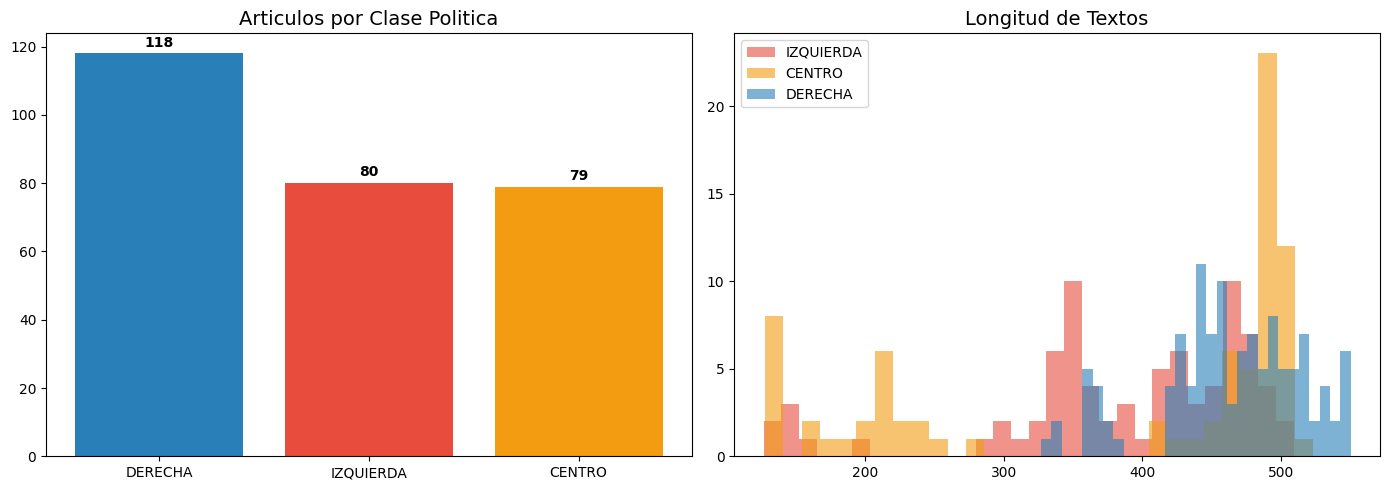

Longitud promedio: 418 caracteres


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = {'IZQUIERDA': '#e74c3c', 'CENTRO': '#f39c12', 'DERECHA': '#2980b9'}

conteos = df['clase'].value_counts()
axes[0].bar(conteos.index, conteos.values, color=[colores[c] for c in conteos.index])
axes[0].set_title('Articulos por Clase Politica', fontsize=14)
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

df['longitud'] = df['texto'].str.len()
for clase, color in colores.items():
    axes[1].hist(df[df['clase'] == clase]['longitud'], alpha=0.6, label=clase, color=color, bins=30)
axes[1].set_title('Longitud de Textos', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig(SAVE_PATH + 'distribucion.png', dpi=150)
plt.show()
print(f'Longitud promedio: {df["longitud"].mean():.0f} caracteres')

## Celda 8 - Preparar Dataset para BETO

In [ ]:
LABEL2ID = {'IZQUIERDA': 0, 'CENTRO': 1, 'DERECHA': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
df['label'] = df['clase'].map(LABEL2ID)

# Balancear clases (mismo n por clase)
min_clase = df['clase'].value_counts().min()
df_bal = df.groupby('clase').apply(lambda x: x.sample(min_clase, random_state=42)).reset_index(drop=True)
print(f'Dataset balanceado: {len(df_bal)} articulos')

# Split 70% train / 15% val / 15% test
df_train, df_temp = train_test_split(df_bal, test_size=0.30, random_state=42, stratify=df_bal['label'])
df_val,   df_test = train_test_split(df_temp, test_size=0.50, random_state=42, stratify=df_temp['label'])
print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

Dataset balanceado: 237 articulos
Train: 165 | Val: 36 | Test: 36


## Celda 9 - Tokenizacion con BETO

In [ ]:
MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['texto'], truncation=True, padding='max_length', max_length=256)

ds_train = Dataset.from_pandas(df_train[['texto', 'label']]).map(tokenize, batched=True)
ds_val   = Dataset.from_pandas(df_val[['texto', 'label']]).map(tokenize, batched=True)
ds_test  = Dataset.from_pandas(df_test[['texto', 'label']]).map(tokenize, batched=True)

for ds in [ds_train, ds_val, ds_test]:
    ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print('Tokenizacion completa')

Map:   0%|          | 0/165 [00:00<?, ? examples/s]

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

Tokenizacion completa


## Celda 10 - Cargar Modelo BETO

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
)
model.to(device)
print(f'Modelo cargado - Parametros: {sum(p.numel() for p in model.parameters()):,}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Modelo cargado - Parametros: 109,853,187


## Celda 11 - Entrenamiento (Fine-tuning)

Con GPU T4 de Colab tarda aprox **15-25 minutos**.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds), 'f1_macro': f1_score(labels, preds, average='macro')}

training_args = TrainingArguments(
    output_dir=MODEL_PATH,
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=50,
    fp16=(device == 'cuda'),
    report_to='none'
)

trainer = Trainer(
    model=model, args=training_args,
    train_dataset=ds_train, eval_dataset=ds_val,
    compute_metrics=compute_metrics
)

print('Entrenando...')
trainer.train()
print('Entrenamiento finalizado!')

## Celda 12 - Evaluacion y Metricas

=== Reporte de Clasificacion ===
              precision    recall  f1-score   support

   IZQUIERDA       0.86      1.00      0.92        12
      CENTRO       0.73      0.67      0.70        12
     DERECHA       0.82      0.75      0.78        12

    accuracy                           0.81        36
   macro avg       0.80      0.81      0.80        36
weighted avg       0.80      0.81      0.80        36



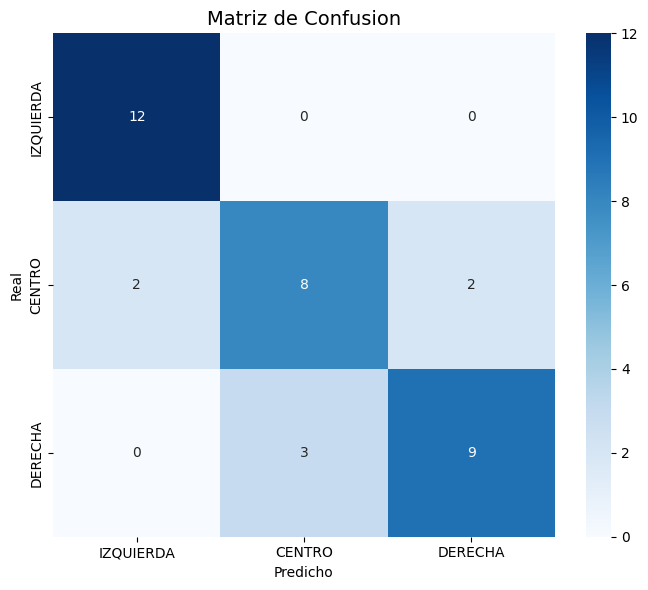

In [ ]:
predictions = trainer.predict(ds_test)
preds  = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print('=== Reporte de Clasificacion ===')
print(classification_report(labels, preds, target_names=['IZQUIERDA', 'CENTRO', 'DERECHA']))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['IZQUIERDA','CENTRO','DERECHA'],
            yticklabels=['IZQUIERDA','CENTRO','DERECHA'])
plt.title('Matriz de Confusion', fontsize=14)
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'confusion_matrix.png', dpi=150)
plt.show()

## Celda 13 - Proba con Noticias Nuevas

Pega cualquier noticia colombiana y ve como la clasifica el modelo.

In [ ]:
def predecir(texto):
    inputs = tokenizer(texto, return_tensors='pt', truncation=True, padding=True, max_length=256).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    probs   = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()
    pred_id = np.argmax(probs)
    print(f'Texto: "{texto[:80]}..."')
    print(f'Prediccion: >>> {ID2LABEL[pred_id]} <<<')
    for clase, prob in zip(['IZQUIERDA', 'CENTRO', 'DERECHA'], probs):
        barra = '|' * int(prob * 40)
        print(f'  {clase:12} {barra} {prob:.1%}')
    print()

# --- Pega aca tus noticias para probar ---
predecir('El gobierno de Petro avanza en la reforma pensional con el respaldo de los sindicatos.')
predecir('La reforma pensional generaria un deficit fiscal que amenaza la estabilidad economica del pais.')
predecir('El Congreso debatio las implicaciones fiscales de la reforma pensional sin llegar a consenso.')


Texto: "El gobierno de Petro avanza en la reforma pensional con el respaldo de los sindi..."
Prediccion: >>> CENTRO <<<
  IZQUIERDA    |||||||||||||| 35.2%
  CENTRO       ||||||||||||||||||||| 53.5%
  DERECHA      |||| 11.3%

Texto: "La reforma pensional generaria un deficit fiscal que amenaza la estabilidad econ..."
Prediccion: >>> CENTRO <<<
  IZQUIERDA    |||||||||||||||| 41.7%
  CENTRO       ||||||||||||||||| 43.5%
  DERECHA      ||||| 14.8%

Texto: "El Congreso debatio las implicaciones fiscales de la reforma pensional sin llega..."
Prediccion: >>> IZQUIERDA <<<
  IZQUIERDA    |||||||||||||||||| 46.9%
  CENTRO       |||||||||||||||| 40.2%
  DERECHA      ||||| 13.0%



In [ ]:
predecir("petro es muy malo")

Texto: "petro es muy malo..."
Prediccion: >>> CENTRO <<<
  IZQUIERDA    ||||||| 18.0%
  CENTRO       |||||||||||||||||||||| 57.4%
  DERECHA      ||||||||| 24.6%



## Celda 14 - Guardar Modelo en Drive

In [ ]:
trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')